# Validation check for P1 and P5 sample simulation

We here test the L1 pipeline data products for the P1 and P5 sample. The production of the following data was done using the corresponding input catalogues and the PLATOnium executions:

- platonium 500 1 1 23 --project L1-pipeline --seed 1234 --sample P1
- platonium 500 1 1 23 --project L1-pipeline --seed 1234 --sample P5

This, we test with star ID 500, N-CAM 1.1 and Q23. We here secure that the seeds are fixed in the random number generator, so we can reproduce the results.

## Import libraries

In [2]:
# Second part libraries
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import median_filter

# PlatoSim libraries
from platosim.simfile import SimFile
from platosim.plot import plotPhotometry
from platosim.utilities import errorcode, normalize
#from platosim.statistics import sortlc, plot_modelfit, plot_residuals, plot_standardized_residuals

# Settings
%matplotlib notebook 
import warnings
warnings.simplefilter("ignore")

# Constants
ppmh = 144   # For a cadence of 25s
model = 'y ~ x'
ms, aa = 3, 0.1

In [9]:
# Choose directory to save and unpack data
inputDir = '/lhome/nicholas/software/workdir/jitterImpact/input/'
dataDir  = '/lhome/nicholas/data/kul20/'

## Create input misalignment models

In [10]:
def matrixMisalignment(x, y, z):   
    r11 = + np.cos(x)*np.cos(z) - np.sin(x)*np.sin(z)*np.sin(y)
    r12 = - np.cos(x)*np.sin(z) - np.sin(x)*np.cos(z)*np.cos(y)
    r13 = + np.sin(x)*np.sin(z)
    r21 = + np.sin(x)*np.cos(z) + np.cos(x)*np.sin(z)*np.cos(y)
    r22 = - np.sin(x)*np.sin(z) - np.cos(x)*np.cos(z)*np.cos(y)
    r23 = - np.cos(x)*np.sin(z)
    r31 = + np.sin(z)*np.sin(y)
    r32 = + np.cos(z)*np.sin(y)
    r33 = - np.cos(y)   
    R = np.array([[r11, r12, r13],
                  [r21, r22, r23],
                  [r31, r32, r33]])
    return R


def changeOfPointing(x, y, z, phi, theta):
    R = np.array([[ 0, -z,  y],
                  [ z,  0, -x],
                  [-y,  x,  0]])
    A = np.array([[np.cos(phi)*np.sin(theta)],
                  [np.sin(phi)*np.sin(theta)], 
                  [1]])
    return np.dot(R,A).T

In [11]:
# Perfect pointing to provisional SPF (ICRS - equatorial)
ra  = 86.79870508
dec = -46.39594703
rot = -4.0
ICRS = np.array([ra, dec, rot])
quarters = np.array([1, 2, 3, 4, 5, 6, 7, 8])
sigma = 3

### Generate PRE file

In [13]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 3.0/3600
b = 6.0/3600

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(len(quarters))])
bb = np.array([np.random.normal(0, b/sigma) for i in range(len(quarters))])

# Corresponding yaw, pitch, roll
y = tt
z = 3 * y
x = bb - z

# ICRS pointing angles
phi   = np.deg2rad(ra)
theta = np.deg2rad(dec)

# Find change to pointing for quarters
coor = np.zeros((len(quarters), 4))
for i in range(len(quarters)):
    data = changeOfPointing(x[i], y[i], z[i], phi, theta)[0]
    coor[i,:] = np.append(quarters[i], data)

# Save file with relative pointing errors [deg]
np.savetxt(f'{inputDir}/PRE.txt', coor, fmt=['%i', '%0.8f', '%0.8f', '%0.8f'])

print('Yaw, Pitch, and Roll angles')
print(x)
print(y)
print(z)

print('\nChange of coordinates [arcsec]')
print(coor*3600)

print('\nNew coordinates [deg]')
for i in range(len(quarters)):
    print(coor[i][1]+ra, coor[i][2]+dec, coor[i][3])

Yaw, Pitch, and Roll angles
[-0.00110172 -0.00172198  0.00177424 -0.00156901  0.00028999 -0.00056485
 -0.000381    0.00023698]
[ 2.12496225e-04  2.94838183e-04 -4.69853371e-04  3.46688587e-04
 -4.77775876e-05 -1.86640671e-04  1.16406353e-04 -6.24567691e-06]
[ 6.37488674e-04  8.84514550e-04 -1.40956011e-03  1.04006576e-03
 -1.43332763e-04 -5.59922012e-04  3.49219060e-04 -1.87370307e-05]

Change of coordinates [arcsec]
[[ 3.60000000e+03  2.42422606e+00  3.87337681e+00  2.89845546e+00]
 [ 7.20000000e+03  3.36360991e+00  6.07036553e+00  4.52484989e+00]
 [ 1.08000000e+04 -5.36024011e+00 -6.18206468e+00 -4.68634730e+00]
 [ 1.44000000e+04  3.95513619e+00  5.49703387e+00  4.13425520e+00]
 [ 1.80000000e+04 -5.45062262e-01 -1.02311588e+00 -7.61746927e-01]
 [ 2.16000000e+04 -2.12925749e+00  2.11496000e+00  1.44299859e+00]
 [ 2.52000000e+04  1.32800155e+00  1.32077513e+00  1.00861299e+00]
 [ 2.88000000e+04 -7.12527141e-02 -8.50393900e-01 -6.17710225e-01]]

New coordinates [deg]
86.7993784761281 -4

### Generate APE file

In [14]:
# Pointing Reproducibility Error (PRE) in P/L reference frame (yaw, pitch, roll)
t = 4.5/60  # [deg]
b = 9.0/60  # [deg]

# Find distribution within 3 sigma of req.
tt = np.array([np.random.normal(0, t/sigma) for i in range(24)])
bb = np.array([np.random.normal(0, b/sigma) for i in range(24)])

# Corresponding yaw, pitch, roll
dy = tt
dz = 3 * dy
dx = bb - dz
mu, sigma = 0, xreq/sigma # mean and standard deviation
s = np.random.normal(mu, sigma, 1000)
count, bins, ignored = plt.hist(s, 30, density=True)
plt.plot(bins, 1/(sigma * np.sqrt(2 * np.pi)) * 
         np.exp( - (bins - mu)**2 / (2 * sigma**2) ),
         linewidth=2, color='r')
plt.show()

# Save APE camera misalignments
out = np.transpose([tt, bb])
np.savetxt('APE.txt', out, fmt='%.8f')

print('Alt, Az, Yaw, Pitch, and Roll alignment error for all 24 N-CAMs [arcmin]')
print(np.transpose([tt, bb, dx, dy, dz])*60)

NameError: name 'xreq' is not defined

## Download data

In [51]:
star = '000000010'

# Varsource
var = pd.read_csv(datadir + f'{star}/varsource_{star}.txt', names=['time', 'dmag'], sep=' ', header=None)
var['time'] = var['time'] / 86400
var['flux'] = (10**(-var['dmag']/2.5) - 1) * 1e6 

# Load L1 pipeline
lc = pd.read_feather(datadir + f'{star}/{star}_Ncam1.1_Q23.ftr')
lc1 = sortlc(lc)

<IPython.core.display.Javascript object>


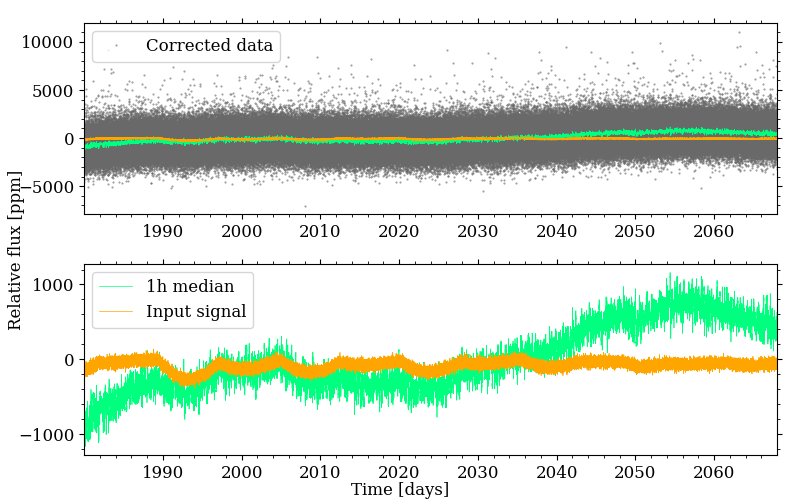

In [57]:
fig, ax = plt.subplots(2, 1, figsize=(8, 5))

# Plot L1 pipeline ligth curve
ax[0].plot(lc1['time'], lc1['flux'], '.', ms=1, c='dimgrey', alpha=0.7, label='Corrected data')
ax[0].plot(lc1['time'], lc1['flux_med'],   '-', c='springgreen', lw=0.5)
ax[0].plot(var['time'], var['flux'],       '-', c='orange', lw=0.5)
ax[0].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[0].legend(loc='upper left')

# Plot L1 pipeline ligth curve
ax[1].plot(lc1['time'], lc1['flux_med'], '-', color='springgreen',   lw=0.5, label='1h median')
ax[1].plot(var['time'], var['flux'],     '-', color='orange', lw=0.5, label='Input signal')
ax[1].set_xlim(lc1['time'].iloc[0], lc1['time'].iloc[-1])
ax[1].legend(loc='upper left')

# Settings
fig.text(0.5, 0.01, 'Time [days]', ha='center')
fig.text(0.01, 0.5, 'Relative flux [ppm]', va='center', rotation='vertical')
plt.tight_layout()
plt.show()

plt.savefig('test.pdf')  